In [1]:
import pandas as pd
import numpy as np 
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# loading the data
df = pd.read_csv('data/cleaned_customers.csv')
df.head()

,CustomerID,Signup_Date,Last_purchase_date,email,Phone_number,Gender_encoded,Country_encoded,Age_scaled,Purchase_scaled,Feedback_scaled
0,NaN,31/12/2024,13/08/2025,unknown@missing.com,0,0.0,1,-0.435539,-0.764246,-0.434743
1,C2,NaN,NaN,user1mail.com,abc123,NaN,1,-0.344951,NaN,-1.084230
2,3,NaN,20/06/2023,user2@mail.com,abc123,NaN,2,-0.047305,NaN,1.297222
3,C4,NaN,13/09/2025,unknown@missing.com,9316267914,NaN,4,-0.332010,NaN,NaN
4,5,09/07/2025,NaN,user4mail.com,9234603292,NaN,4,1.686808,-0.764246,NaN


In [3]:
# we will select which columns are used for the training
feature_columns = [  'Age_scaled', 
    'Purchase_scaled', 
    'Feedback_scaled', 
    'Gender_encoded', 
    'Country_encoded'
]
# create the feature matrix
x = df[feature_columns]
print(len(feature_columns))
x.head()

5


,Age_scaled,Purchase_scaled,Feedback_scaled,Gender_encoded,Country_encoded
0,-0.435539,-0.764246,-0.434743,0.0,1
1,-0.344951,NaN,-1.084230,NaN,1
2,-0.047305,NaN,1.297222,NaN,2
3,-0.332010,NaN,NaN,NaN,4
4,1.686808,-0.764246,NaN,NaN,4


In [4]:
# Initilize the model meaning we expect 10% of the data to be anomalous
# seting contamination = 0.1 which means 
isolation_model = IsolationForest(
    contamination = 0.1,
    random_state = 42,
    n_estimators = 100)

# we will train the model
isolation_model.fit(x)

,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [5]:
predictions = isolation_model.predict(x)
# anomoly score
anomaly_scores = isolation_model.decision_function(x)

# now add the results back to the data frame
df['IF_Prediction'] = predictions
df['IF_Anomaly_Score'] = anomaly_scores

# count how may anomalies are found
anomaly_count = (predictions == -1).sum()
normal_count = (predictions == 1).sum()

print(f" Normal customers: {normal_count}")
print(f" Anomalous customers: {anomaly_count}")
print(f" Anomaly Rate: {(anomaly_count / len(df)) * 100:.2f}%")


 Normal customers: 9000
 Anomalous customers: 1000
 Anomaly Rate: 10.00%


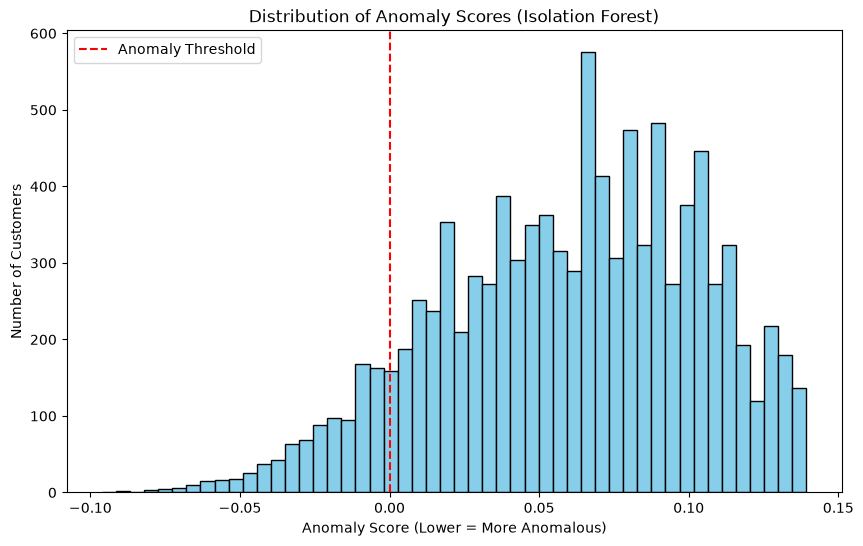

In [6]:
plt.figure(figsize=(10,6))
plt.hist(anomaly_scores, bins= 50, color ='skyblue', edgecolor = 'black')
plt.axvline(x=0, color='red', linestyle='--', label='Anomaly Threshold')
plt.title('Distribution of Anomaly Scores (Isolation Forest)')
plt.xlabel('Anomaly Score (Lower = More Anomalous)')
plt.ylabel('Number of Customers')
plt.legend(loc='upper left')
plt.show()

In [7]:
# seeing whata re top animolies
top_anomalies = df.sort_values('IF_Anomaly_Score').head(5)

# wnat the columns that are needed not all
top_anomalies[['CustomerID', 'Age_scaled', 'Purchase_scaled', 'Feedback_scaled', 'IF_Anomaly_Score']]

,CustomerID,Age_scaled,Purchase_scaled,Feedback_scaled,IF_Anomaly_Score
3835,C3836,1.686808,2.371700,-0.001752,-0.096142
3968,3969,1.686808,1.804693,-0.001752,-0.091367
2389,NaN,1.686808,1.931201,-0.651239,-0.087851
7088,C7088,1.686808,1.941365,-0.001752,-0.081168
7372,7373,1.686808,1.700189,-0.218248,-0.078249


In [8]:
df.to_csv('data/cleaned_customers_with_if.csv', index=False) # copying this top_animolies data